In [1]:
import os
print("Current Working Directory:")
print(os.getcwd())

import os

os.chdir(r"C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis")

print(os.getcwd())
print(os.listdir("data"))


Current Working Directory:
c:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis\clustering
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
['train.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Load and Preprocess Data
df = pd.read_csv('data/train.csv')
df_model = df.drop(columns=['Employee_Id'])

# Encode Categorical features
le = LabelEncoder()
df_model['Work_Life_Balance'] = le.fit_transform(df_model['Work_Life_Balance'])
df_model['Lives_With_Family'] = le.fit_transform(df_model['Lives_With_Family'])
df_model = pd.get_dummies(df_model, columns=['Work_From', 'Working_State'])

# Feature Scaling (Crucial for distance-based models like K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model.drop(columns=['Stress_Level']))

# 2. K-Means Clustering (K=3 for Low, Moderate, High Stress)
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. Evaluation: Silhouette Score
score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score: {score:.4f}")

# 4. Map Clusters to Stress Groups
# We calculate the mean actual stress level per cluster to label them
cluster_map = df.groupby('Cluster')['Stress_Level'].mean().sort_values().index
mapping = {cluster_map[0]: 'Low Stress', cluster_map[1]: 'Moderate Stress', cluster_map[2]: 'High Stress'}
df['Stress_Group'] = df['Cluster'].map(mapping)

print(df[['Employee_Id', 'Stress_Level', 'Stress_Group']].head())

Silhouette Score: 0.1342
  Employee_Id  Stress_Level     Stress_Group
0     EMP0001             3       Low Stress
1     EMP0002             4       Low Stress
2     EMP0003             1      High Stress
3     EMP0004             2  Moderate Stress
4     EMP0005             5       Low Stress


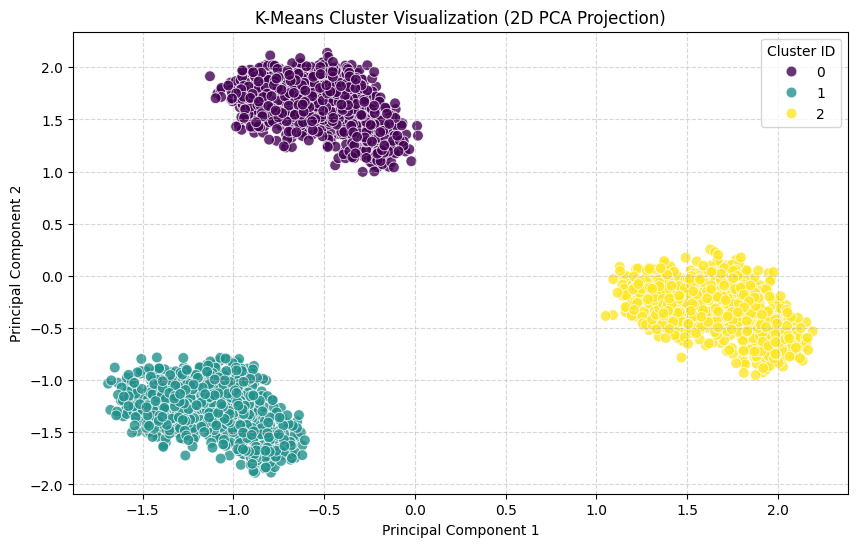

In [3]:
# --- Cluster Visualization (PCA) ---
from sklearn.decomposition import PCA

# Reduce dimensions to 2 for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=df['Cluster'], 
    palette='viridis', 
    s=60, alpha=0.8
)

plt.title('K-Means Cluster Visualization (2D PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster ID', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

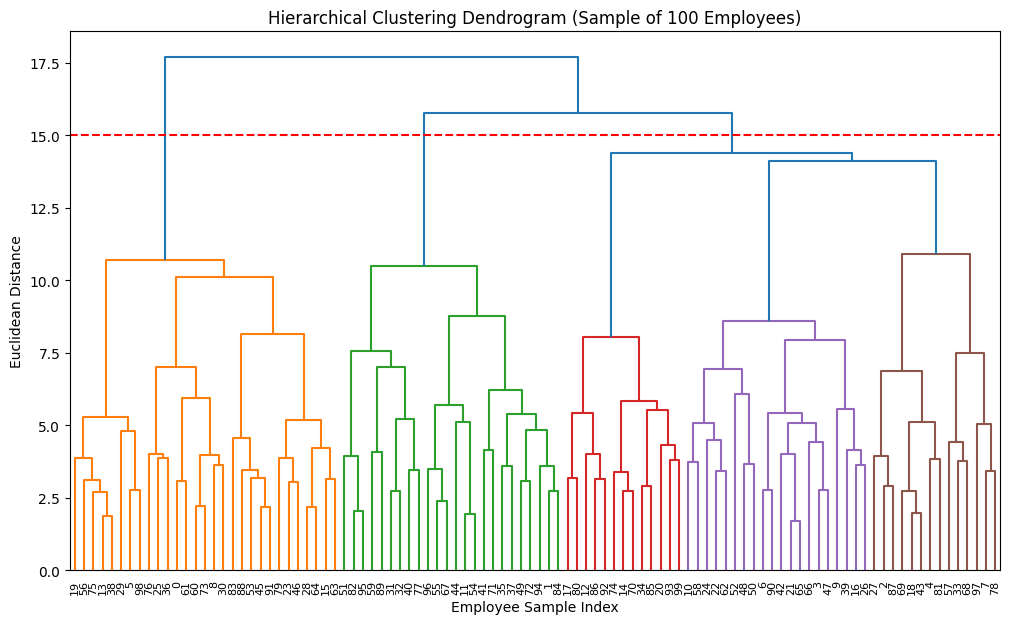

In [4]:
# --- Dendrogram Visualization ---
from scipy.cluster.hierarchy import dendrogram, linkage

# Use Ward's method to find clusters based on variance
# Sampling 100 points for clear visibility
X_sample = X_scaled[np.random.choice(X_scaled.shape[0], 100, replace=False)]
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(
    Z, 
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
)

plt.title('Hierarchical Clustering Dendrogram (Sample of 100 Employees)')
plt.xlabel('Employee Sample Index')
plt.ylabel('Euclidean Distance')
plt.axhline(y=15, color='r', linestyle='--') # Example threshold line
plt.show()

In [6]:
# Evaluation Metrics
print(f"Silhouette Score: {silhouette_score(X_scaled, df['Cluster']):.4f}")


Silhouette Score: 0.1342
